# Experiment: 05 Temperature Robustness

Objective:
- Compare DeepSeek GSM8K geometry signal under greedy decoding and temperature sampling.
- Measure how entropy and geometry behave across layers and controls.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

candidate_dirs = [Path.cwd(), Path.cwd() / "notebooks", *[parent / "notebooks" for parent in Path.cwd().parents]]
for candidate in candidate_dirs:
    if (candidate / "_viz_utils.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/_viz_utils.py from current working directory")

import matplotlib.pyplot as plt
import numpy as np

import _viz_utils as vu

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})


In [2]:
greedy = vu.load_result_json("deepseek", "gsm8k")
temp = vu.load_result_json("deepseek_temp", "gsm8k")

def to_rows(model_name: str, record: dict) -> list[dict]:
    rows = []
    entropy = record["entropy_baseline"]["roc_auc_mean"]
    for layer_key, payload in record["layers"].items():
        layer = int(layer_key)
        rows.append(
            {
                "model": model_name,
                "layer": layer,
                "entropy": entropy,
                "mahal": payload["mahalanobis_only"]["roc_auc_mean"],
                "combined": payload["combined"]["roc_auc_mean"],
                "delta_raw": payload["delta_vs_entropy"],
                "delta_len": payload["length_controlled_delta"],
            }
        )
    return sorted(rows, key=lambda r: r["layer"])

greedy_rows = to_rows("greedy", greedy)
temp_rows = to_rows("temp=0.6", temp)


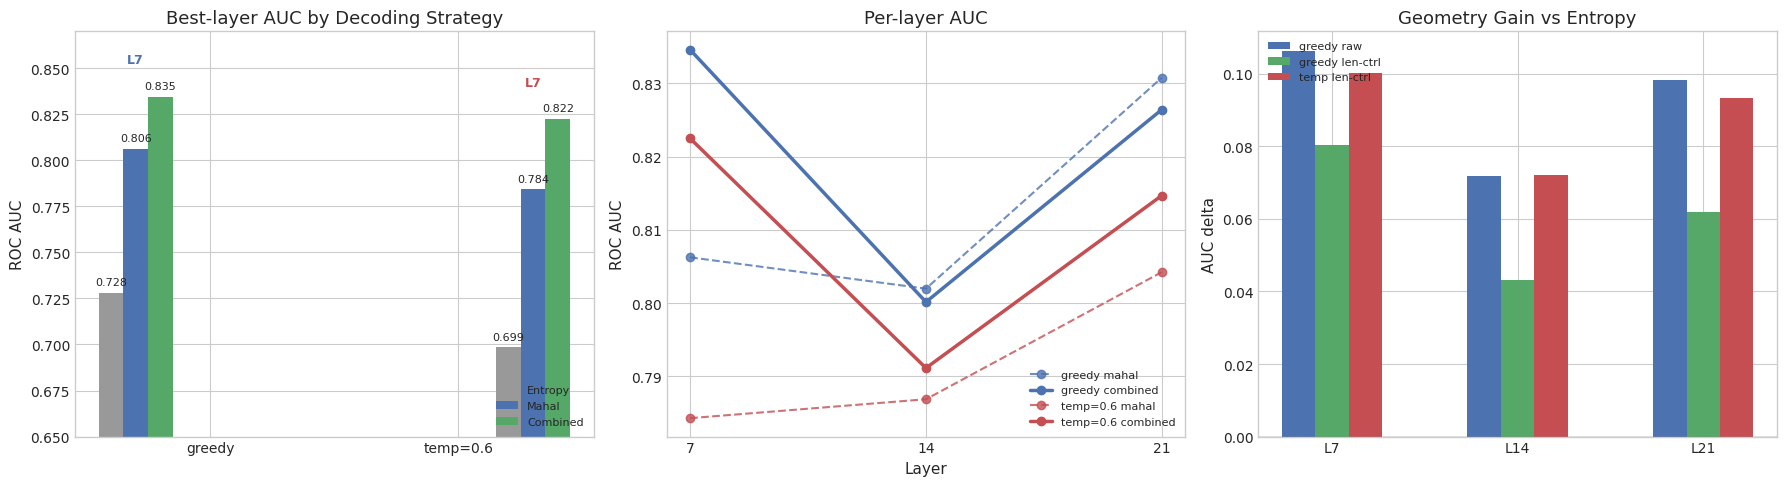

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_metric = {"Entropy": "#999999", "Mahal": "#4C72B0", "Combined": "#55A868"}
strategy_colors = {"greedy": "#4C72B0", "temp=0.6": "#C44E52"}
strategy_offsets = {"greedy": -0.3, "temp=0.6": 0.3}

for idx, (rows, label) in enumerate([(greedy_rows, "greedy"), (temp_rows, "temp=0.6")]):
    best = max(rows, key=lambda r: r["combined"])
    off = strategy_offsets[label]
    color = strategy_colors[label]
    for metric_off, (key, mcolor) in zip([-0.1, 0, 0.1],
                                         [("entropy", "#999999"), ("mahal", "#4C72B0"), ("combined", "#55A868")]):
        v = best[key]
        bar = axes[0].bar(idx + off + metric_off, v, width=0.1, color=mcolor)
        axes[0].text(idx + off + metric_off, v + 0.003, f"{v:.3f}",
                     ha="center", va="bottom", fontsize=8)
    axes[0].text(idx + off, best["combined"] + 0.018, f"L{best['layer']}",
                 ha="center", fontsize=9, color=color, fontweight="bold")

# Dummy legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#999999", label="Entropy"),
    Patch(facecolor="#4C72B0", label="Mahal"),
    Patch(facecolor="#55A868", label="Combined"),
]
axes[0].set_title("Best-layer AUC by Decoding Strategy")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["greedy", "temp=0.6"])
axes[0].set_ylabel("ROC AUC")
axes[0].set_ylim(0.65, 0.87)
axes[0].legend(handles=legend_elements, loc="lower right", fontsize=8)

for rows, color, label in [(greedy_rows, "#4C72B0", "greedy"), (temp_rows, "#C44E52", "temp=0.6")]:
    layers_l = [r["layer"] for r in rows]
    axes[1].plot(layers_l, [r["mahal"] for r in rows], marker="o", linestyle="--", color=color,
                 alpha=0.8, label=f"{label} mahal")
    axes[1].plot(layers_l, [r["combined"] for r in rows], marker="o", linestyle="-", color=color,
                 linewidth=2.5, label=f"{label} combined")
axes[1].set_title("Per-layer AUC")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("ROC AUC")
axes[1].set_xticks([r["layer"] for r in greedy_rows])
axes[1].legend(loc="lower right", fontsize=8)

width = 0.18
layers_arr = np.array([r["layer"] for r in greedy_rows])
x = np.arange(len(layers_arr))
axes[2].bar(x - width, [r["delta_raw"] for r in greedy_rows], width=width,
            color="#4C72B0", label="greedy raw")
axes[2].bar(x, [r["delta_len"] for r in greedy_rows], width=width,
            color="#55A868", label="greedy len-ctrl")
axes[2].bar(x + width, [r["delta_len"] for r in temp_rows], width=width,
            color="#C44E52", label="temp len-ctrl")
axes[2].axhline(0.0, color="black", linewidth=1, alpha=0.5)
axes[2].set_title("Geometry Gain vs Entropy")
axes[2].set_xticks(x)
axes[2].set_xticklabels([f"L{l}" for l in layers_arr])
axes[2].set_ylabel("AUC delta")
axes[2].legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()
